# Distillation Results — v6

This notebook loads the 24 evaluated distillation combinations:
3 teachers × 4 students × 2 conditions.

Local JSONL files are the primary source of truth. Runtime and throughput statistics are pulled from the matching WandB run summaries when present, and the notebook falls back to the WandB API only if a local summary is missing.


In [9]:
from __future__ import annotations

import json
import re
from functools import lru_cache
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

try:
    import wandb
except ImportError:
    wandb = None

plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)

PROJECT_ROOT = Path("../../").resolve()
RESULTS_ROOT = PROJECT_ROOT / "data/safety_experiment/distillation"
WANDB_ROOT = PROJECT_ROOT / "logs/wandb/wandb"

TEACHERS = {
    "moonshotai-kimi-k2.5": "Kimi K2.5",
    "openai-gpt-oss-120b": "GPT-OSS 120B",
    "RedHatAI-gemma-3-27b-it-quantized.w4a16": "Gemma 3 27B (w4a16)",
}

STUDENTS = {
    "gemma-3-12b": "Gemma 3 12B",
    "llama-3.1-8b": "Llama 3.1 8B",
    "ministral-8b": "Ministral 8B",
    "qwen3-8b": "Qwen3 8B",
}

CONDITIONS = {
    "without_intent": "Without Intent",
    "with_intent": "With Intent",
}

DATASETS = {
    "aegis": "Aegis",
    "annotated-intents": "Annotated Intents",
    "toxic-chat": "Toxic Chat",
    "wildguardmix": "WildGuardMix",
    "xstest": "XSTest",
}

# Used to pull runtime/token keys from WandB summaries.
EVAL_SUFFIX = {
    "without_intent": "without_intent",
    "with_intent": "with_intent",
}

TEACHER_ORDER = list(TEACHERS.keys())
STUDENT_ORDER = list(STUDENTS.keys())
CONDITION_ORDER = list(CONDITIONS.keys())
DATASET_ORDER = list(DATASETS.keys())


def _to_binary_label(value):
    if value is None:
        return None
    if isinstance(value, bool):
        return 1 if value else 0
    if isinstance(value, (int, float)):
        return int(value)

    text = str(value).strip().lower()
    if text in {"harmful", "unsafe", "1", "true", "yes"}:
        return 1
    if text in {"safe", "benign", "0", "false", "no"}:
        return 0
    return None


def find_jsonl_file(dataset_dir: Path) -> Path | None:
    if not dataset_dir.exists():
        return None

    preferred = sorted(dataset_dir.glob("*_classification.jsonl"))
    if preferred:
        return preferred[0]

    any_jsonl = sorted(dataset_dir.glob("*.jsonl"))
    if any_jsonl:
        return any_jsonl[0]

    return None


def compute_binary_metrics(jsonl_path: Path) -> dict:
    y_true = []
    y_pred = []
    missing_predictions = 0
    num_rows = 0

    with open(jsonl_path) as handle:
        for line in handle:
            line = line.strip()
            if not line:
                continue
            num_rows += 1
            record = json.loads(line)

            true_value = (
                record.get("true_harm_binary")
                if record.get("true_harm_binary") is not None
                else record.get("true_harm")
            )
            pred_value = (
                record.get("predicted_harm")
                if record.get("predicted_harm") is not None
                else record.get("pred_harm")
            )

            y_t = _to_binary_label(true_value)
            y_p = _to_binary_label(pred_value)

            if y_t is None or y_p is None:
                missing_predictions += 1
                continue

            y_true.append(y_t)
            y_pred.append(y_p)

    num_scored = len(y_true)
    if num_scored == 0:
        return {
            "num_rows": num_rows,
            "num_scored": 0,
            "missing_predictions": missing_predictions,
            "accuracy": 0.0,
            "precision": 0.0,
            "recall": 0.0,
            "f1": 0.0,
        }

    return {
        "num_rows": num_rows,
        "num_scored": num_scored,
        "missing_predictions": missing_predictions,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }


@lru_cache(maxsize=None)
def load_run_summary(run_name: str) -> dict:
    if WANDB_ROOT.exists():
        for summary_path in sorted(WANDB_ROOT.glob(f"**/*{run_name}*/files/wandb-summary.json")):
            try:
                with open(summary_path) as handle:
                    payload = json.load(handle)
                payload["_source"] = "local"
                return payload
            except Exception:
                continue

    if wandb is not None:
        try:
            api = wandb.Api()
            runs = api.runs("Jazhyc/intention-jailbreak", filters={"display_name": run_name})
            if runs:
                payload = dict(runs[0].summary)
                payload["_source"] = "api"
                return payload
        except Exception:
            pass

    return {"_source": "missing"}


def summary_stat(summary: dict, key: str):
    value = summary.get(key)
    if value is not None:
        return value
    if key == "runtime" and summary.get("_runtime") is not None:
        return summary.get("_runtime")
    wandb_meta = summary.get("_wandb")
    if isinstance(wandb_meta, dict):
        return wandb_meta.get(key)
    return None


def load_combo_rows() -> tuple[pd.DataFrame, list[str]]:
    rows = []
    missing = []

    for teacher_slug, teacher_name in TEACHERS.items():
        for student_slug, student_name in STUDENTS.items():
            for condition_slug, condition_name in CONDITIONS.items():
                combo_dir = RESULTS_ROOT / teacher_slug / student_slug / condition_slug
                run_name = f"distill--{teacher_slug}--{student_slug}--{condition_slug}"
                summary = load_run_summary(run_name)

                if not combo_dir.exists():
                    missing.append(f"{teacher_slug}/{student_slug}/{condition_slug}: missing combo directory")
                    continue

                for dataset_slug, dataset_name in DATASETS.items():
                    dataset_dir = combo_dir / dataset_slug
                    jsonl_path = find_jsonl_file(dataset_dir)
                    if jsonl_path is None:
                        missing.append(f"{teacher_slug}/{student_slug}/{condition_slug}/{dataset_slug}: missing JSONL")
                        continue

                    metrics = compute_binary_metrics(jsonl_path)
                    eval_suffix = EVAL_SUFFIX[condition_slug]
                    prefix = f"{dataset_slug}/{eval_suffix}"
                    wandb_elapsed_s = summary.get(f"{prefix}/elapsed_s")
                    wandb_total_tokens = summary.get(f"{prefix}/total_tokens")
                    wandb_tokens_per_second = summary.get(f"{prefix}/tokens_per_second")

                    rows.append(
                        {
                            "teacher_slug": teacher_slug,
                            "teacher": teacher_name,
                            "student_slug": student_slug,
                            "student": student_name,
                            "condition_slug": condition_slug,
                            "condition": condition_name,
                            "dataset_slug": dataset_slug,
                            "dataset": dataset_name,
                            "run_name": run_name,
                            "jsonl_path": str(jsonl_path.relative_to(PROJECT_ROOT)),
                            "wandb_source": summary.get("_source", "missing"),
                            "wandb_runtime_s": summary_stat(summary, "runtime"),
                            "wandb_elapsed_s": wandb_elapsed_s,
                            "wandb_total_tokens": wandb_total_tokens,
                            "wandb_tokens_per_second": wandb_tokens_per_second,
                            **metrics,
                        }
                    )

    return pd.DataFrame(rows), missing

Loaded 24/24 combinations and 120/120 dataset files.
WandB source counts: {'missing': 24}


,teacher,student,condition,datasets_loaded,accuracy,precision,recall,f1,tokens,elapsed_s,tok_per_s,wandb_runtime_s,wandb_source
9,Kimi K2.5,Gemma 3 12B,Without Intent,5,0.833,0.714,0.842,0.768,0,0.0,nan,nan,missing
8,Kimi K2.5,Gemma 3 12B,With Intent,5,0.845,0.736,0.849,0.784,0,0.0,nan,nan,missing
11,Kimi K2.5,Llama 3.1 8B,Without Intent,5,0.814,0.696,0.809,0.743,0,0.0,nan,nan,missing
10,Kimi K2.5,Llama 3.1 8B,With Intent,5,0.825,0.759,0.720,0.736,0,0.0,nan,nan,missing
13,Kimi K2.5,Ministral 8B,Without Intent,5,0.823,0.693,0.863,0.763,0,0.0,nan,nan,missing
12,Kimi K2.5,Ministral 8B,With Intent,5,0.842,0.773,0.775,0.773,0,0.0,nan,nan,missing
15,Kimi K2.5,Qwen3 8B,Without Intent,5,0.830,0.752,0.772,0.761,0,0.0,nan,nan,missing
14,Kimi K2.5,Qwen3 8B,With Intent,5,0.834,0.747,0.798,0.769,0,0.0,nan,nan,missing
17,GPT-OSS 120B,Gemma 3 12B,Without Intent,5,0.860,0.760,0.873,0.810,0,0.0,nan,nan,missing
16,GPT-OSS 120B,Gemma 3 12B,With Intent,5,0.852,0.765,0.847,0.801,0,0.0,nan,nan,missing



Dataset-level details (first 12 rows):


,teacher,student,condition,dataset,accuracy,precision,recall,f1,num_rows,missing_predictions,wandb_elapsed_s,wandb_total_tokens,wandb_tokens_per_second
0,Kimi K2.5,Gemma 3 12B,Without Intent,Aegis,0.768,0.759,0.835,0.795,1964,0,nan,nan,nan
1,Kimi K2.5,Gemma 3 12B,Without Intent,Annotated Intents,0.694,0.667,0.738,0.701,173,0,nan,nan,nan
2,Kimi K2.5,Gemma 3 12B,Without Intent,Toxic Chat,0.919,0.458,0.776,0.576,5083,0,nan,nan,nan
3,Kimi K2.5,Gemma 3 12B,Without Intent,WildGuardMix,0.867,0.832,0.877,0.854,1699,0,nan,nan,nan
4,Kimi K2.5,Gemma 3 12B,Without Intent,XSTest,0.918,0.853,0.985,0.914,450,0,nan,nan,nan
5,Kimi K2.5,Gemma 3 12B,With Intent,Aegis,0.783,0.787,0.820,0.803,1964,1,nan,nan,nan
6,Kimi K2.5,Gemma 3 12B,With Intent,Annotated Intents,0.740,0.729,0.738,0.734,173,0,nan,nan,nan
7,Kimi K2.5,Gemma 3 12B,With Intent,Toxic Chat,0.931,0.508,0.818,0.626,5083,0,nan,nan,nan
8,Kimi K2.5,Gemma 3 12B,With Intent,WildGuardMix,0.857,0.802,0.899,0.848,1699,0,nan,nan,nan
9,Kimi K2.5,Gemma 3 12B,With Intent,XSTest,0.913,0.855,0.970,0.909,450,0,nan,nan,nan


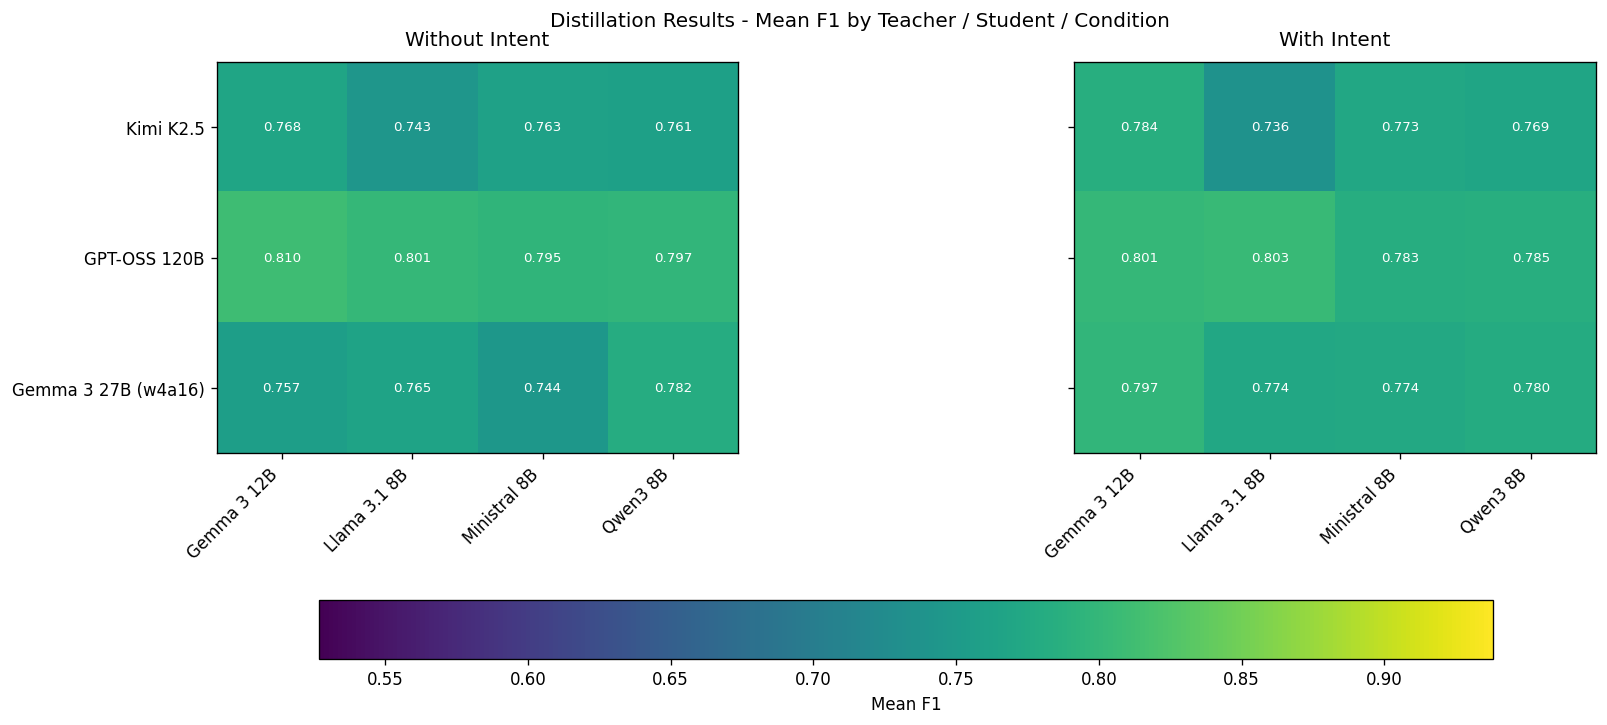

In [10]:
records_df, missing_items = load_combo_rows()

expected_combos = len(TEACHERS) * len(STUDENTS) * len(CONDITIONS)
expected_rows = expected_combos * len(DATASETS)

if records_df.empty:
    raise RuntimeError("No distillation results were found.")

combo_df = (
    records_df.groupby(["teacher_slug", "teacher", "student_slug", "student", "condition_slug", "condition", "run_name", "wandb_source"], as_index=False)
    .agg(
        datasets_loaded=("dataset_slug", "nunique"),
        files_loaded=("jsonl_path", "count"),
        mean_accuracy=("accuracy", "mean"),
        mean_precision=("precision", "mean"),
        mean_recall=("recall", "mean"),
        mean_f1=("f1", "mean"),
        total_rows=("num_rows", "sum"),
        scored_rows=("num_scored", "sum"),
        missing_predictions=("missing_predictions", "sum"),
        total_tokens=("wandb_total_tokens", "sum"),
        total_elapsed_s=("wandb_elapsed_s", "sum"),
        wandb_runtime_s=("wandb_runtime_s", "first"),
    )
)
_elapsed_denom = combo_df["total_elapsed_s"].replace(0, np.nan)
combo_df["computed_tokens_per_second"] = combo_df["total_tokens"] / _elapsed_denom

combo_df = combo_df.assign(
    teacher_rank=combo_df["teacher_slug"].map({slug: idx for idx, slug in enumerate(TEACHER_ORDER)}),
    student_rank=combo_df["student_slug"].map({slug: idx for idx, slug in enumerate(STUDENT_ORDER)}),
    condition_rank=combo_df["condition_slug"].map({slug: idx for idx, slug in enumerate(CONDITION_ORDER)}),
).sort_values(["teacher_rank", "student_rank", "condition_rank"]).drop(columns=["teacher_rank", "student_rank", "condition_rank"])

records_df = records_df.assign(
    teacher_rank=records_df["teacher_slug"].map({slug: idx for idx, slug in enumerate(TEACHER_ORDER)}),
    student_rank=records_df["student_slug"].map({slug: idx for idx, slug in enumerate(STUDENT_ORDER)}),
    condition_rank=records_df["condition_slug"].map({slug: idx for idx, slug in enumerate(CONDITION_ORDER)}),
    dataset_rank=records_df["dataset_slug"].map({slug: idx for idx, slug in enumerate(DATASET_ORDER)}),
).sort_values(["teacher_rank", "student_rank", "condition_rank", "dataset_rank"]).drop(columns=["teacher_rank", "student_rank", "condition_rank", "dataset_rank"])

print(f"Loaded {len(combo_df)}/{expected_combos} combinations and {len(records_df)}/{expected_rows} dataset files.")
print(f"WandB source counts: {combo_df['wandb_source'].value_counts(dropna=False).to_dict()}")
if missing_items:
    print("Missing items:")
    for item in missing_items:
        print(f"  - {item}")

combo_display = combo_df[[
    "teacher",
    "student",
    "condition",
    "datasets_loaded",
    "mean_accuracy",
    "mean_precision",
    "mean_recall",
    "mean_f1",
    "total_tokens",
    "total_elapsed_s",
    "computed_tokens_per_second",
    "wandb_runtime_s",
    "wandb_source",
]]

combo_display = combo_display.rename(columns={
    "mean_accuracy": "accuracy",
    "mean_precision": "precision",
    "mean_recall": "recall",
    "mean_f1": "f1",
    "total_tokens": "tokens",
    "total_elapsed_s": "elapsed_s",
    "computed_tokens_per_second": "tok_per_s",
    "wandb_runtime_s": "wandb_runtime_s",
})

for col in ["accuracy", "precision", "recall", "f1", "tokens", "elapsed_s", "tok_per_s", "wandb_runtime_s"]:
    combo_display[col] = pd.to_numeric(combo_display[col], errors="coerce")

display(
    combo_display.style.format({
        "accuracy": "{:.3f}",
        "precision": "{:.3f}",
        "recall": "{:.3f}",
        "f1": "{:.3f}",
        "tokens": "{:.0f}",
        "elapsed_s": "{:.1f}",
        "tok_per_s": "{:.1f}",
        "wandb_runtime_s": "{:.0f}",
    })
)

print("\nDataset-level details (first 12 rows):")
records_preview = records_df[[
    "teacher",
    "student",
    "condition",
    "dataset",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "num_rows",
    "missing_predictions",
    "wandb_elapsed_s",
    "wandb_total_tokens",
    "wandb_tokens_per_second",
]].head(12).copy()

for col in ["accuracy", "precision", "recall", "f1", "wandb_elapsed_s", "wandb_total_tokens", "wandb_tokens_per_second"]:
    records_preview[col] = pd.to_numeric(records_preview[col], errors="coerce")

display(
    records_preview.style.format({
        "accuracy": "{:.3f}",
        "precision": "{:.3f}",
        "recall": "{:.3f}",
        "f1": "{:.3f}",
        "wandb_elapsed_s": "{:.1f}",
        "wandb_total_tokens": "{:.0f}",
        "wandb_tokens_per_second": "{:.1f}",
    })
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8), sharey=True, constrained_layout=True)
heatmap_min = float(records_df['f1'].min())
heatmap_max = float(records_df['f1'].max())
for ax, condition_slug in zip(axes, CONDITION_ORDER):
    pivot = (
        combo_df[combo_df["condition_slug"] == condition_slug]
        .pivot(index="teacher", columns="student", values="mean_f1")
        .reindex(index=[TEACHERS[k] for k in TEACHER_ORDER], columns=[STUDENTS[k] for k in STUDENT_ORDER])
    )
    image = ax.imshow(pivot.values, vmin=heatmap_min, vmax=heatmap_max, cmap="viridis")
    ax.set_title(CONDITIONS[condition_slug], pad=10)
    ax.set_xticks(np.arange(len(pivot.columns)), labels=pivot.columns, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(pivot.index)), labels=pivot.index)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            cell_value = pivot.iloc[i, j]
            text_color = "white" if (cell_value - heatmap_min) / (heatmap_max - heatmap_min + 1e-12) > 0.5 else "black"
            ax.text(j, i, f"{cell_value:.3f}", ha="center", va="center", color=text_color, fontsize=8)

fig.colorbar(image, ax=axes, location="bottom", shrink=0.8, pad=0.08, label="Mean F1")
fig.suptitle("Distillation Results - Mean F1 by Teacher / Student / Condition", y=1.02)
plt.show()

Paired condition comparison at the teacher/student level (F1):


condition_slug,teacher,student,without_intent,with_intent,intent_delta
8,GPT-OSS 120B,Gemma 3 12B,0.810,0.801,-0.008
9,GPT-OSS 120B,Llama 3.1 8B,0.801,0.803,+0.002
10,GPT-OSS 120B,Ministral 8B,0.795,0.783,-0.012
11,GPT-OSS 120B,Qwen3 8B,0.797,0.785,-0.013
0,Gemma 3 27B (w4a16),Gemma 3 12B,0.757,0.797,+0.040
1,Gemma 3 27B (w4a16),Llama 3.1 8B,0.765,0.774,+0.009
2,Gemma 3 27B (w4a16),Ministral 8B,0.744,0.774,+0.030
3,Gemma 3 27B (w4a16),Qwen3 8B,0.782,0.780,-0.002
4,Kimi K2.5,Gemma 3 12B,0.768,0.784,+0.016
5,Kimi K2.5,Llama 3.1 8B,0.743,0.736,-0.006


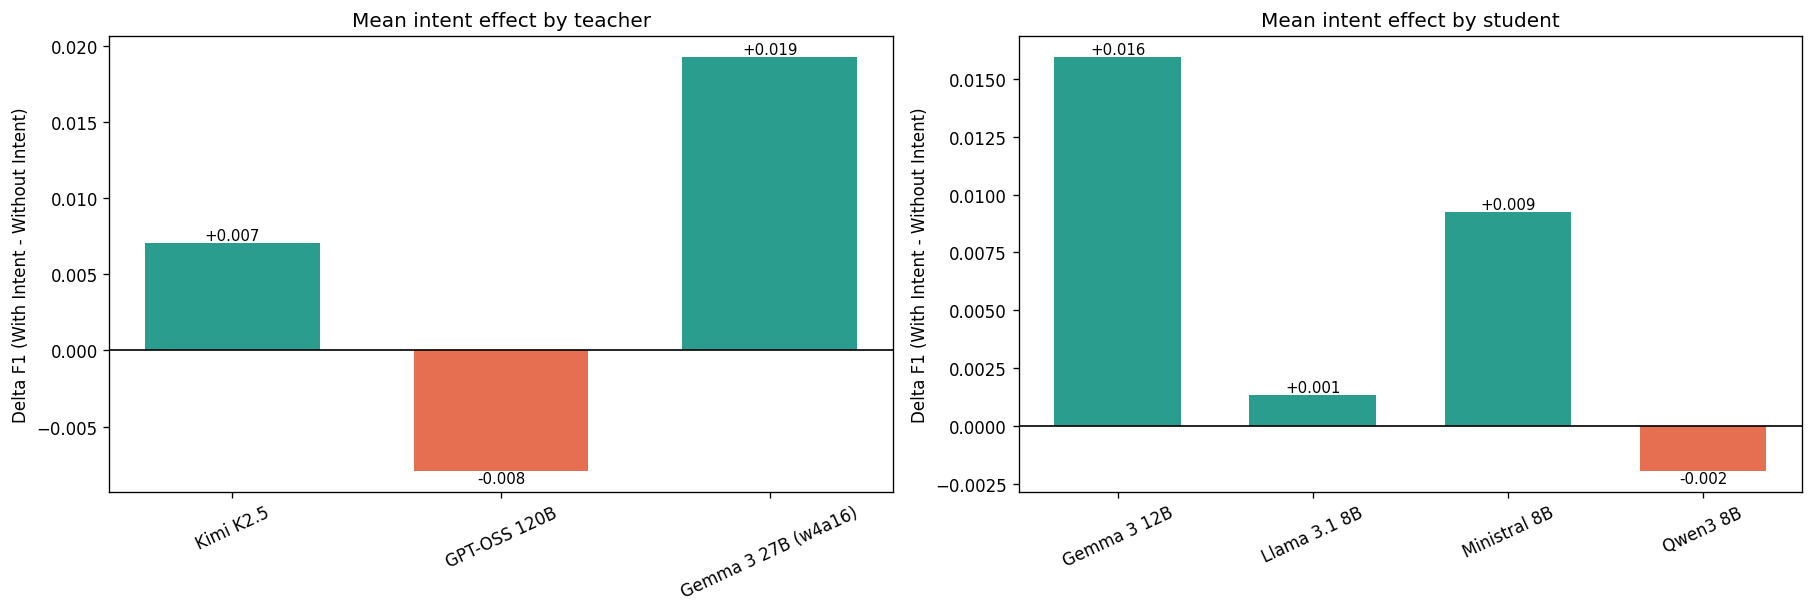

Summary of the intent effect:
  Mean delta across teacher/student pairs: +0.0062
  Pairs with positive delta: 7/12


In [11]:
# Compare the intent condition as a paired delta: With Intent - Without Intent.
condition_f1 = (
    combo_df.pivot_table(
        index=["teacher_slug", "teacher", "student_slug", "student"],
        columns="condition_slug",
        values="mean_f1",
        aggfunc="mean",
    )
    .reset_index()
)

condition_f1["intent_delta"] = condition_f1["with_intent"] - condition_f1["without_intent"]

pairwise_display = condition_f1[[
    "teacher",
    "student",
    "without_intent",
    "with_intent",
    "intent_delta",
]].copy()

teacher_effect = (
    condition_f1.groupby(["teacher_slug", "teacher"], as_index=False)
    .agg(
        mean_delta=("intent_delta", "mean"),
        std_delta=("intent_delta", "std"),
        mean_without=("without_intent", "mean"),
        mean_with=("with_intent", "mean"),
    )
    .assign(teacher_rank=lambda df: df["teacher_slug"].map({slug: idx for idx, slug in enumerate(TEACHER_ORDER)}))
    .sort_values("teacher_rank")
    .drop(columns="teacher_rank")
)

student_effect = (
    condition_f1.groupby(["student_slug", "student"], as_index=False)
    .agg(
        mean_delta=("intent_delta", "mean"),
        std_delta=("intent_delta", "std"),
        mean_without=("without_intent", "mean"),
        mean_with=("with_intent", "mean"),
    )
    .assign(student_rank=lambda df: df["student_slug"].map({slug: idx for idx, slug in enumerate(STUDENT_ORDER)}))
    .sort_values("student_rank")
    .drop(columns="student_rank")
)

print("Paired condition comparison at the teacher/student level (F1):")
display(
    pairwise_display.sort_values(["teacher", "student"]).style.format({
        "without_intent": "{:.3f}",
        "with_intent": "{:.3f}",
        "intent_delta": "{:+.3f}",
    })
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

for axis, effect_df, label, order_key in [
    (axes[0], teacher_effect, "teacher", "teacher"),
    (axes[1], student_effect, "student", "student"),
]:
    colors = ["#2A9D8F" if value >= 0 else "#E76F51" for value in effect_df["mean_delta"]]
    axis.bar(effect_df[label], effect_df["mean_delta"], color=colors, width=0.65)
    axis.axhline(0, color="black", linewidth=1)
    axis.set_title(f"Mean intent effect by {label}")
    axis.set_ylabel("Delta F1 (With Intent - Without Intent)")
    axis.tick_params(axis="x", rotation=25)
    for x_pos, value in enumerate(effect_df["mean_delta"]):
        axis.text(x_pos, value, f"{value:+.3f}", ha="center", va="bottom" if value >= 0 else "top", fontsize=9)

plt.show()

print("Summary of the intent effect:")
print(
    f"  Mean delta across teacher/student pairs: {condition_f1['intent_delta'].mean():+.4f}"
)
print(
    f"  Pairs with positive delta: {(condition_f1['intent_delta'] > 0).sum()}/{len(condition_f1)}"
)


condition_slug,dataset,without_intent,with_intent,intent_delta
2,Toxic Chat,0.620,0.650,+0.030
3,WildGuardMix,0.852,0.857,+0.005
1,Annotated Intents,0.695,0.696,+0.001
4,XSTest,0.898,0.896,-0.002
0,Aegis,0.804,0.801,-0.003


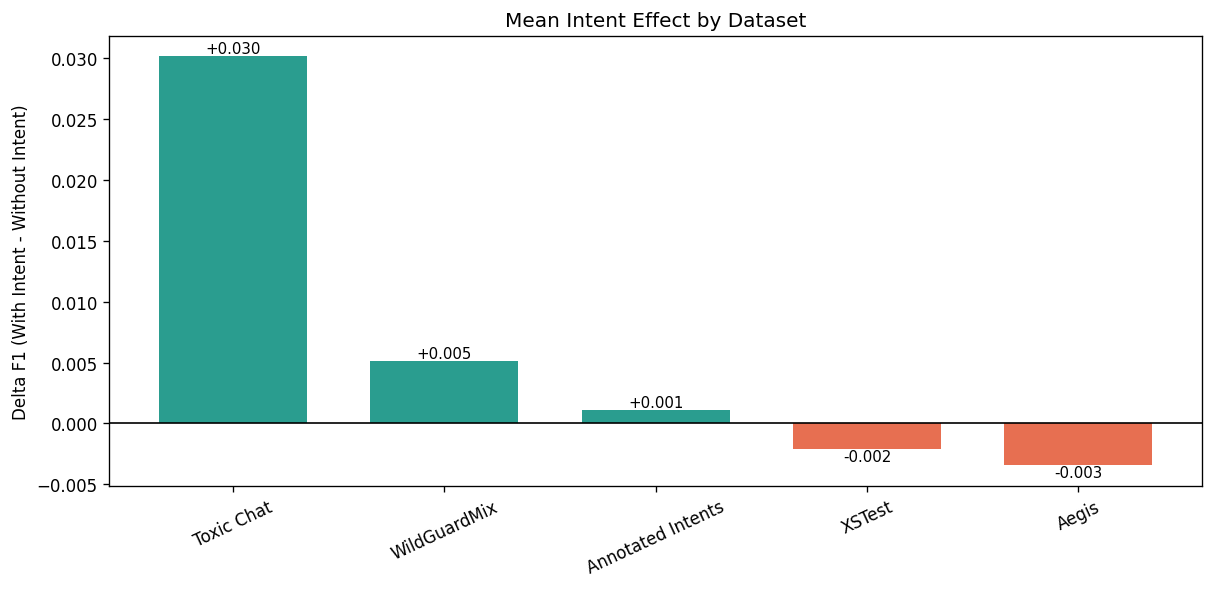

Dataset-level intent effect summary:
  Mean delta across datasets: +0.0062
  Datasets with positive delta: 3/5

Best and worst datasets by intent delta:


condition_slug,dataset,without_intent,with_intent,intent_delta,rank
0,Toxic Chat,0.620,0.650,+0.030,top
1,WildGuardMix,0.852,0.857,+0.005,top
2,Annotated Intents,0.695,0.696,+0.001,top
3,Aegis,0.804,0.801,-0.003,bottom
4,XSTest,0.898,0.896,-0.002,bottom
5,Annotated Intents,0.695,0.696,+0.001,bottom


In [12]:
dataset_f1 = (
    records_df.pivot_table(
        index=["dataset_slug", "dataset"],
        columns="condition_slug",
        values="f1",
        aggfunc="mean",
    )
    .reset_index()
)

dataset_f1["intent_delta"] = dataset_f1["with_intent"] - dataset_f1["without_intent"]

dataset_display = dataset_f1[[
    "dataset",
    "without_intent",
    "with_intent",
    "intent_delta",
]].copy()

dataset_display = dataset_display.sort_values("intent_delta", ascending=False)

display(
    dataset_display.style.format({
        "without_intent": "{:.3f}",
        "with_intent": "{:.3f}",
        "intent_delta": "{:+.3f}",
    })
)

fig, ax = plt.subplots(figsize=(10, 4.8), constrained_layout=True)
colors = ["#2A9D8F" if value >= 0 else "#E76F51" for value in dataset_display["intent_delta"]]
ax.bar(dataset_display["dataset"], dataset_display["intent_delta"], color=colors, width=0.7)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Mean Intent Effect by Dataset")
ax.set_ylabel("Delta F1 (With Intent - Without Intent)")
ax.tick_params(axis="x", rotation=25)
for x_pos, value in enumerate(dataset_display["intent_delta"]):
    ax.text(x_pos, value, f"{value:+.3f}", ha="center", va="bottom" if value >= 0 else "top", fontsize=9)
plt.show()

print("Dataset-level intent effect summary:")
print(f"  Mean delta across datasets: {dataset_f1['intent_delta'].mean():+.4f}")
print(f"  Datasets with positive delta: {(dataset_f1['intent_delta'] > 0).sum()}/{len(dataset_f1)}")

print("\nBest and worst datasets by intent delta:")
display(
    pd.concat(
        [
            dataset_display.head(3).assign(rank="top"),
            dataset_display.tail(3).sort_values("intent_delta").assign(rank="bottom"),
        ],
        ignore_index=True,
    ).style.format({
        "without_intent": "{:.3f}",
        "with_intent": "{:.3f}",
        "intent_delta": "{:+.3f}",
    })
)


,Best distillation,WildGuard
Average,0.829,0.823
Aegis,0.828,0.809
Toxic Chat,0.678,0.651
WildGuardMix,0.874,0.887
XSTest,0.938,0.945


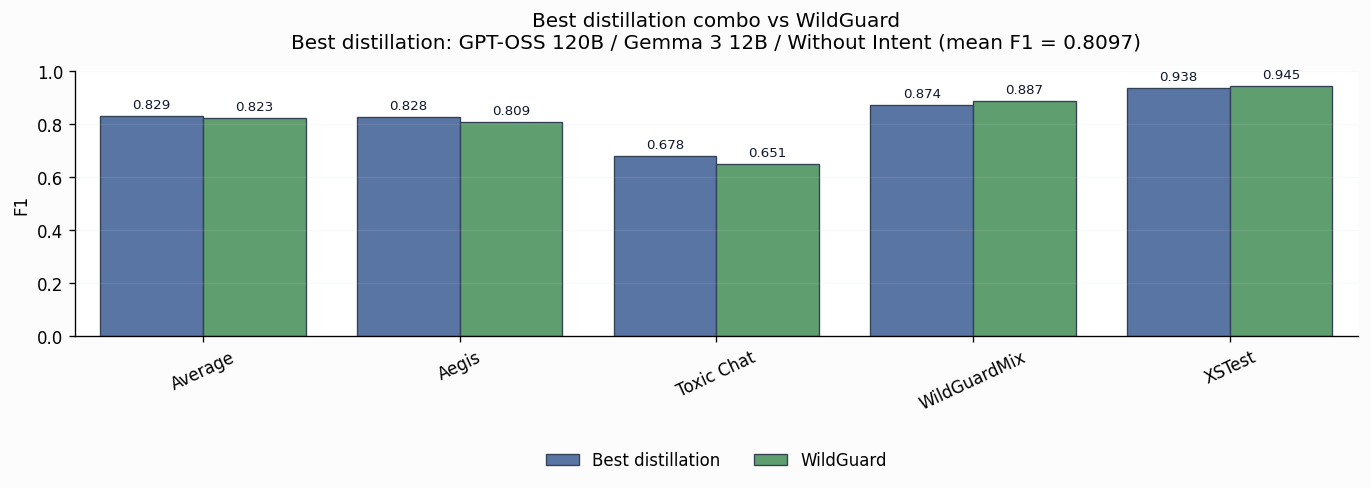

Best combo selected programmatically: teacher=GPT-OSS 120B, student=Gemma 3 12B, condition=Without Intent, mean_f1=0.8097
Distillation average across datasets: 0.8295
WildGuard average across datasets: 0.8232


In [13]:
# Best overall result: compare the top distillation combo against WildGuard across datasets.

def load_jsonl(path: Path) -> list[dict]:
    rows = []
    with open(path) as handle:
        for line in handle:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def compute_metrics(results: list[dict]) -> dict:
    tp = fp = tn = fn = 0
    for record in results:
        true_harm = record.get("true_harm_binary") or record.get("true_harm")
        pred_harm = record.get("predicted_harm")
        if true_harm is None or pred_harm is None:
            continue
        true_lower = str(true_harm).lower()
        pred_lower = str(pred_harm).lower()
        if true_lower == "harmful" and pred_lower == "harmful":
            tp += 1
        elif true_lower == "safe" and pred_lower == "harmful":
            fp += 1
        elif true_lower == "safe" and pred_lower == "safe":
            tn += 1
        elif true_lower == "harmful" and pred_lower == "safe":
            fn += 1
    total = tp + fp + tn + fn
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {"accuracy": (tp + tn) / total if total else 0.0, "precision": precision, "recall": recall, "f1": f1}


best_combo = combo_df.sort_values("mean_f1", ascending=False).iloc[0]
best_teacher = best_combo["teacher"]
best_student = best_combo["student"]
best_condition = best_combo["condition"]
best_score = float(best_combo["mean_f1"])

best_records = records_df[
    (records_df["teacher"] == best_teacher)
    & (records_df["student"] == best_student)
    & (records_df["condition"] == best_condition)
].copy()

best_summary = (
    best_records.groupby("dataset", as_index=False)["f1"]
    .mean()
    .rename(columns={"dataset": "dataset", "f1": "f1"})
    .query("dataset != 'Annotated Intents'")
    .sort_values("dataset")
    .reset_index(drop=True)
)

safety_results_root = PROJECT_ROOT / "data/safety_experiment"
wildguard_paths = {
    "Aegis": safety_results_root / "aegis" / "allenai_wildguard_wildguard_classification.jsonl",
    "Toxic Chat": safety_results_root / "toxic-chat" / "allenai_wildguard_wildguard_classification.jsonl",
    "WildGuardMix": safety_results_root / "wildguardmix" / "allenai_wildguard_wildguard_classification.jsonl",
    "XSTest": safety_results_root / "xstest" / "allenai_wildguard_wildguard_classification.jsonl",
}

wildguard_rows = []
for dataset, path in wildguard_paths.items():
    wildguard_rows.append({"dataset": dataset, "model": "WildGuard", **compute_metrics(load_jsonl(path))})

wildguard_summary = pd.DataFrame(wildguard_rows)[["dataset", "model", "f1"]]

comparison_df = pd.concat(
    [
        best_summary.assign(model="Best distillation"),
        wildguard_summary,
    ],
    ignore_index=True,
 )

average_df = comparison_df.groupby("model", as_index=False)["f1"].mean().assign(dataset="Average")
comparison_df = pd.concat([comparison_df, average_df], ignore_index=True)

dataset_order = ["Average"] + sorted(d for d in comparison_df["dataset"].unique() if d != "Average")
model_order = ["Best distillation", "WildGuard"]
comparison_df["dataset"] = pd.Categorical(comparison_df["dataset"], categories=dataset_order, ordered=True)
comparison_df["model"] = pd.Categorical(comparison_df["model"], categories=model_order, ordered=True)
comparison_df = comparison_df.sort_values(["dataset", "model"]).reset_index(drop=True)

display(comparison_df.pivot(index="dataset", columns="model", values="f1").reindex(dataset_order).rename_axis(index=None, columns=None).style.format("{:.3f}"))

fig, ax = plt.subplots(figsize=(13.8, 5.8))
fig.patch.set_facecolor("#fcfcfc")
ax.set_facecolor("white")
palette = {"Best distillation": sns.color_palette("deep")[0], "WildGuard": sns.color_palette("deep")[2]}

sns.barplot(
    data=comparison_df,
    x="dataset",
    y="f1",
    hue="model",
    order=dataset_order,
    hue_order=model_order,
    palette=palette,
    ax=ax,
    edgecolor="#334155",
    linewidth=0.8,
    errorbar=None,
)

ax.set_title(
    f"Best distillation combo vs WildGuard\n"
    f"Best distillation: {best_teacher} / {best_student} / {best_condition} (mean F1 = {best_score:.4f})",
    pad=14,
)
ax.set_xlabel("")
ax.xaxis.label.set_visible(False)
ax.set_ylabel("F1")
ax.set_ylim(0, min(1.0, max(comparison_df["f1"].max() * 1.12, 0.05)))
ax.tick_params(axis="x", rotation=25, labelsize=10)
ax.grid(axis="y", color="#cbd5e1", alpha=0.12, linewidth=0.8)

for container in ax.containers:
    ax.bar_label(container, labels=[f"{bar.get_height():.3f}" for bar in container], padding=3, fontsize=8, color="#0f172a")

ax.legend(title=None, loc="upper center", bbox_to_anchor=(0.5, -0.38), ncol=2, frameon=False)
sns.despine(ax=ax, left=False, bottom=False)
fig.subplots_adjust(bottom=0.50)
plt.show()

print(f"Best combo selected programmatically: teacher={best_teacher}, student={best_student}, condition={best_condition}, mean_f1={best_score:.4f}")
print(f"Distillation average across datasets: {comparison_df[comparison_df['model'] == 'Best distillation']['f1'].mean():.4f}")
print(f"WildGuard average across datasets: {comparison_df[comparison_df['model'] == 'WildGuard']['f1'].mean():.4f}")
